#### 1.5 import

In [8]:
import sklearn
import numpy as np
np.random.seed(13)

import matplotlib.pyplot as plt
%matplotlib inline

In [9]:
from sklearn import datasets
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import LinearSVC

#### 1.6 선형 서포트 벡터 머신 적용

In [10]:
iris = datasets.load_iris()
X = iris['data'][:, (2,3)]
y = (iris['target']==2).astype(np.float64)

svm_clf = Pipeline([
    ('scaler', StandardScaler()),
    ('linear_svc', LinearSVC(C=1, loss='hinge', random_state=13))
])

svm_clf.fit(X, y)

Pipeline(steps=[('scaler', StandardScaler()),
                ('linear_svc', LinearSVC(C=1, loss='hinge', random_state=13))])

#### 1.7 예측

In [11]:
svm_clf.predict([[5.5,1.7]])

array([1.])

#### 1.10 연습용 데이터 생성 using make_moons

In [12]:
from sklearn.datasets import make_moons
X, y = make_moons(n_samples=100, noise=0.15, random_state=13)

X.shape, y.shape

((100, 2), (100,))

#### 1.11 데이터 그리는 함수 - 이해되시나요?

In [14]:
def plot_dataset(X, y, axes):
    plt.plot(X[:, 0][y==0], X[:, 1][y==0], 'bs')
    plt.plot(X[:, 0][y==0], X[:, 1][y==1], 'g^')
    plt.axis(axes)
    plt.grid(True, which='both')
    plt.xlabel(r'$x_1$', fontsize=20)
    plt.ylabel(r'$x_2$', fontsize=20, rotation=0)

c:\users\user\anaconda3\envs\nltk\lib\site-packages\matplotlib\backends\backend_agg.py:238: RuntimeWarning: Glyph 8722 missing from current font.
  font.set_text(s, 0.0, flags=flags)
c:\users\user\anaconda3\envs\nltk\lib\site-packages\matplotlib\backends\backend_agg.py:201: RuntimeWarning: Glyph 8722 missing from current font.
  font.set_text(s, 0, flags=flags)


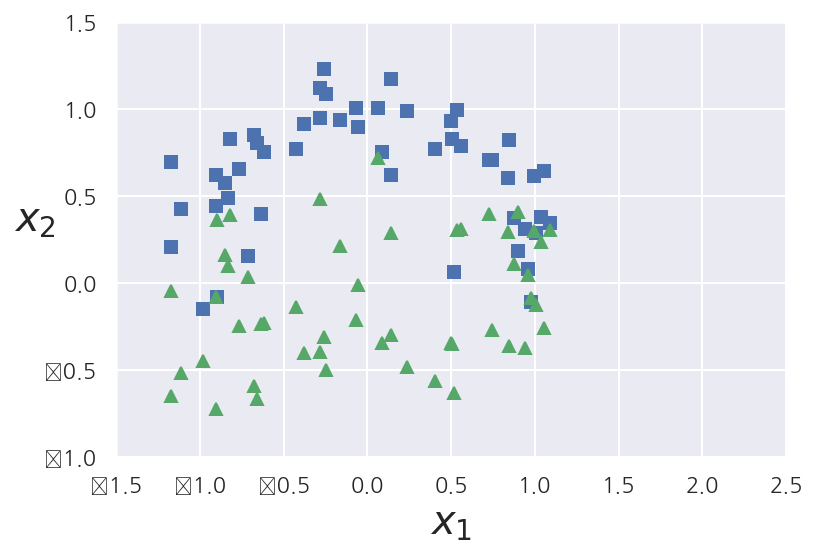

In [15]:
plot_dataset(X, y, [-1.5, 2.5, -1, 1.5])
plt.show()

#### 1.13 선형 SVM에 도전

In [16]:
polynomial_svm_clf = Pipeline([
    ('scaler', StandardScaler()),
    ('svm_clf', LinearSVC(C=10, loss='hinge', random_state=13))
])

polynomial_svm_clf.fit(X,y)

Pipeline(steps=[('scaler', StandardScaler()),
                ('svm_clf', LinearSVC(C=10, loss='hinge', random_state=13))])

#### 1.14 결정경계를 그려주는 함수

In [17]:
def plot_predictions(clf, axes):
    x0s = np.linspace(axes[0], axes[1], 100)
    x1s = np.linspace(axes[0], axes[1], 100)
    x0, x1 = np.meshgrid(x0s, x1s)
    X = np.c_[x0.ravel(), x1.ravel()]
    y_pred = clf.predict(X).reshape(x0.shape)
    y_decision = clf.decision_function(X).reshape(x0.shape)
    plt.contourf(x0, x1, y_pred, cmap=plt.cm.brg, alpha=0.2)
    plt.contourf(x0, x1, y_decision, cmap=plt.cm.brg, alpha=0.1)

#### 1.15 결과~ 누가 선형(linear) 아니랄까봐~

c:\users\user\anaconda3\envs\nltk\lib\site-packages\matplotlib\backends\backend_agg.py:238: RuntimeWarning: Glyph 8722 missing from current font.
  font.set_text(s, 0.0, flags=flags)
c:\users\user\anaconda3\envs\nltk\lib\site-packages\matplotlib\backends\backend_agg.py:201: RuntimeWarning: Glyph 8722 missing from current font.
  font.set_text(s, 0, flags=flags)


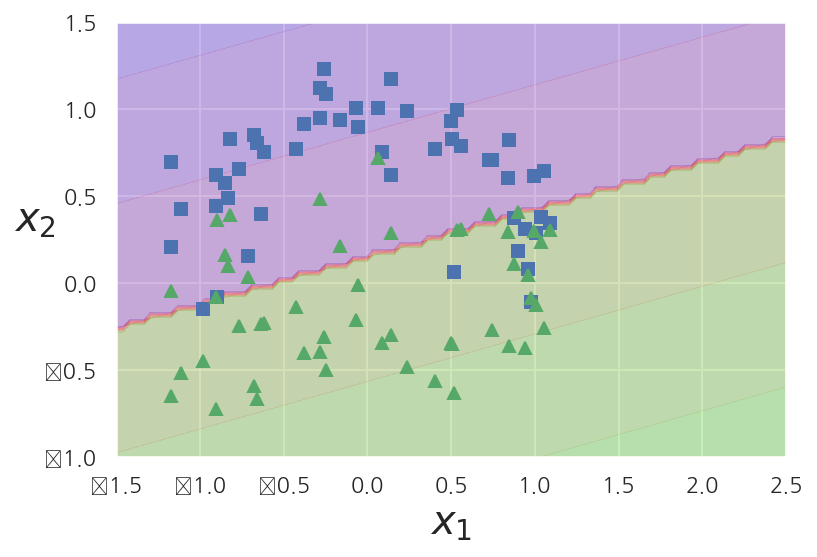

In [18]:
plot_predictions(polynomial_svm_clf, [-1.5, 2.5, -1, 1.5])
plot_dataset(X, y, [-1.5, 2.5, -1, 1.5])
plt.show()

#### 1.16 우리 PolynomialFeatures를 배웠는데 기억나나요?

#### 1.17 PolynomialFeatures

In [19]:
from sklearn.preprocessing import PolynomialFeatures
X_tmp = np.arange(6).reshape(3, 2)
X_tmp

array([[0, 1],
       [2, 3],
       [4, 5]])

#### 1.18 2차식으로 확장하기

In [20]:
poly = PolynomialFeatures(2)
poly.fit_transform(X_tmp)

array([[ 1.,  0.,  1.,  0.,  0.,  1.],
       [ 1.,  2.,  3.,  4.,  6.,  9.],
       [ 1.,  4.,  5., 16., 20., 25.]])

#### 1.19 interaction 항만 표현하기

In [21]:
poly = PolynomialFeatures(degree=2, interaction_only=True)
poly.fit_transform(X_tmp)

array([[ 1.,  0.,  1.,  0.],
       [ 1.,  2.,  3.,  6.],
       [ 1.,  4.,  5., 20.]])

#### 1.20 bias항 빼기

In [22]:
poly = PolynomialFeatures(degree=2, interaction_only=True, include_bias=False)
poly.fit_transform(X_tmp)

array([[ 0.,  1.,  0.],
       [ 2.,  3.,  6.],
       [ 4.,  5., 20.]])

#### 1.21 그럼 선형 SVM에 다항 특성을 가미해서 분류해보기?

In [24]:
polynomial_svm_clf = Pipeline([
    ('poly_features', PolynomialFeatures(degree=3)),
    ('scaler', StandardScaler()),
    ('svm_clf', LinearSVC(C=10, loss='hinge', random_state=13))
])

polynomial_svm_clf.fit(X,y)

Pipeline(steps=[('poly_features', PolynomialFeatures(degree=3)),
                ('scaler', StandardScaler()),
                ('svm_clf', LinearSVC(C=10, loss='hinge', random_state=13))])

#### 1.22 결과

c:\users\user\anaconda3\envs\nltk\lib\site-packages\matplotlib\backends\backend_agg.py:238: RuntimeWarning: Glyph 8722 missing from current font.
  font.set_text(s, 0.0, flags=flags)
c:\users\user\anaconda3\envs\nltk\lib\site-packages\matplotlib\backends\backend_agg.py:201: RuntimeWarning: Glyph 8722 missing from current font.
  font.set_text(s, 0, flags=flags)


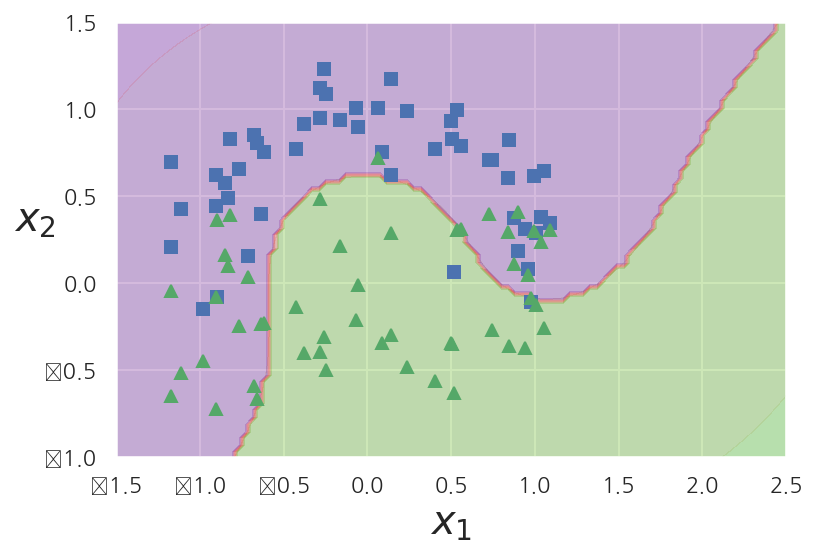

In [25]:
plot_predictions(polynomial_svm_clf, [-1.5, 2.5, -1, 1.5])
plot_dataset(X, y, [-1.5, 2.5, -1, 1.5])
plt.show()

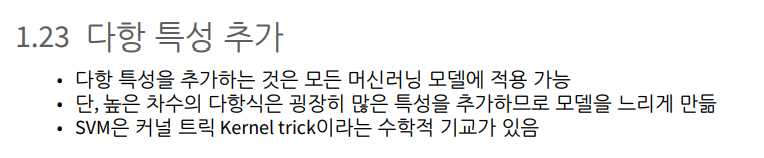

#### 1.24 SVC에서 kernel 옵션을 추가

In [26]:
from sklearn.svm import SVC

poly_kernel_svm_clf = Pipeline([
    ('scaler', StandardScaler()),
    ('svm_clf', SVC(kernel='poly', degree=3, coef0=1, C=5))
])

poly_kernel_svm_clf.fit(X, y)

Pipeline(steps=[('scaler', StandardScaler()),
                ('svm_clf', SVC(C=5, coef0=1, kernel='poly'))])

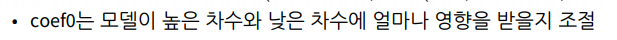

#### 1.25 결과

c:\users\user\anaconda3\envs\nltk\lib\site-packages\matplotlib\backends\backend_agg.py:238: RuntimeWarning: Glyph 8722 missing from current font.
  font.set_text(s, 0.0, flags=flags)
c:\users\user\anaconda3\envs\nltk\lib\site-packages\matplotlib\backends\backend_agg.py:201: RuntimeWarning: Glyph 8722 missing from current font.
  font.set_text(s, 0, flags=flags)


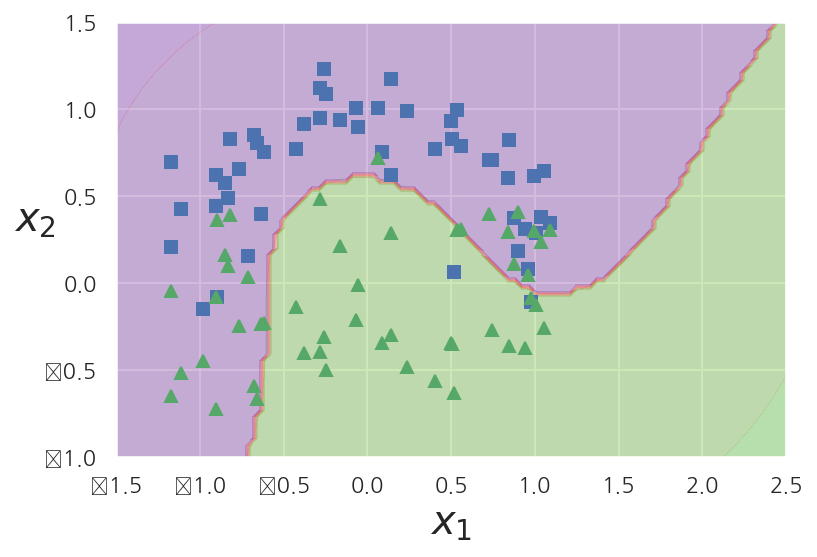

In [27]:
plot_predictions(poly_kernel_svm_clf, [-1.5, 2.5, -1, 1.5])
plot_dataset(X, y, [-1.5, 2.5, -1, 1.5])
plt.show()

#### 1.30 가우시안 RBF를 적용한 SVC

In [28]:
rbf_kernel_svm_clf = Pipeline([
    ('scaler', StandardScaler()),
    ('svm_clf', SVC(kernel='rbf', gamma=5, C=0.001))
])
rbf_kernel_svm_clf.fit(X, y)

Pipeline(steps=[('scaler', StandardScaler()),
                ('svm_clf', SVC(C=0.001, gamma=5))])

#### 1.31 결과

c:\users\user\anaconda3\envs\nltk\lib\site-packages\matplotlib\backends\backend_agg.py:238: RuntimeWarning: Glyph 8722 missing from current font.
  font.set_text(s, 0.0, flags=flags)
c:\users\user\anaconda3\envs\nltk\lib\site-packages\matplotlib\backends\backend_agg.py:201: RuntimeWarning: Glyph 8722 missing from current font.
  font.set_text(s, 0, flags=flags)


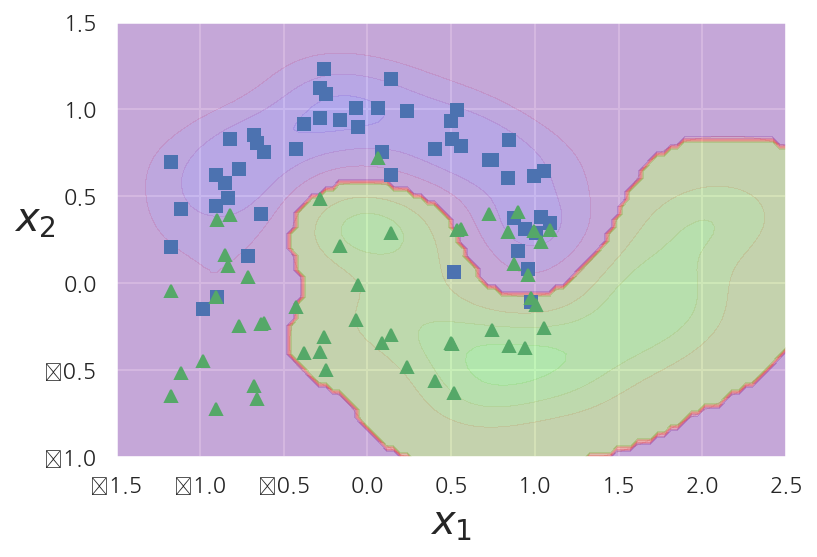

In [29]:
plot_predictions(rbf_kernel_svm_clf, [-1.5, 2.5, -1, 1.5])
plot_dataset(X, y, [-1.5, 2.5, -1, 1.5])
plt.show()

#### 1.32 튜닝해야할 대상이 많아지는 것은 조금 슬프지만

In [30]:
rbf_kernel_svm_clf = Pipeline([
    ('scaler', StandardScaler()),
    ('svm_clf', SVC(kernel='rbf', gamma=5, C=1000))
])
rbf_kernel_svm_clf.fit(X, y)

Pipeline(steps=[('scaler', StandardScaler()),
                ('svm_clf', SVC(C=1000, gamma=5))])

#### 1.33 데이터마다의 특성이 워낙 다르므로 알아두어야 함

c:\users\user\anaconda3\envs\nltk\lib\site-packages\matplotlib\backends\backend_agg.py:238: RuntimeWarning: Glyph 8722 missing from current font.
  font.set_text(s, 0.0, flags=flags)
c:\users\user\anaconda3\envs\nltk\lib\site-packages\matplotlib\backends\backend_agg.py:201: RuntimeWarning: Glyph 8722 missing from current font.
  font.set_text(s, 0, flags=flags)


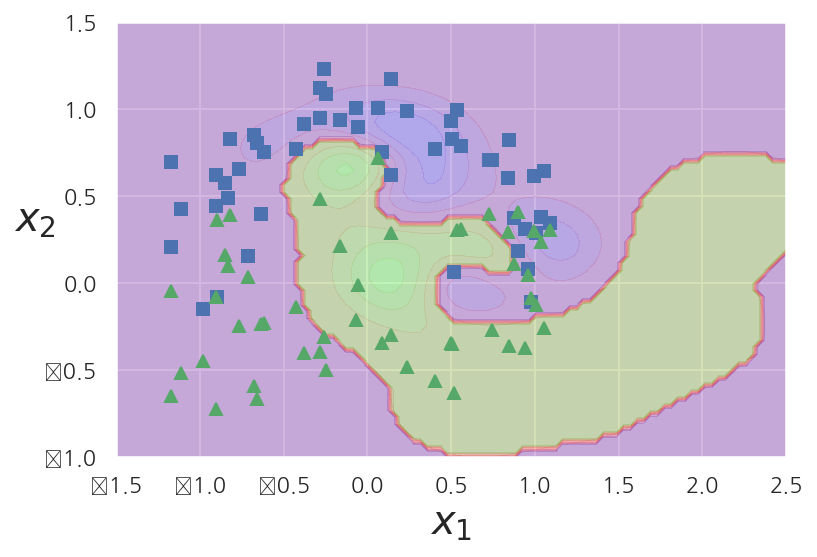

In [32]:
plot_predictions(rbf_kernel_svm_clf, [-1.5, 2.5, -1, 1.5])
plot_dataset(X, y, [-1.5, 2.5, -1, 1.5])
plt.show()

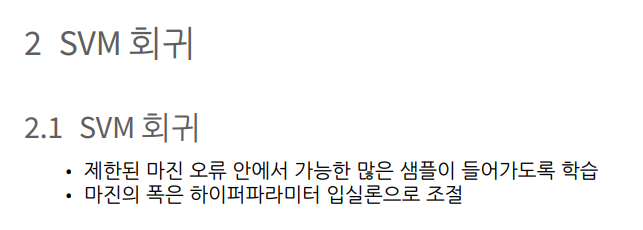

#### 2.2 테스트용 데이터

In [2]:
np.random.seed(13)
m = 50
X = 2 * np.random.rand(m, 1)
y = (4 + 3 * X + np.random.randn(m,1)).ravel()

#### 2.3 SVM 회귀: LinearSVR

In [3]:
from sklearn.svm import LinearSVR

svm_reg = LinearSVR(epsilon=1.5, random_state=13)
svm_reg.fit(X, y)

LinearSVR(epsilon=1.5, random_state=13)

#### 2.4 입실론 값을 바꿔서 학습

In [5]:
svm_reg1 = LinearSVR(epsilon=1.5, random_state=13)
svm_reg2 = LinearSVR(epsilon=0.5, random_state=13)
svm_reg1.fit(X, y)
svm_reg2.fit(X, y)

LinearSVR(epsilon=0.5, random_state=13)

#### 2.5 참값과 예측값과 입실론을 비교해서 support vector를 계산 하는 함수

In [7]:
def find_support_vectors(svm_reg, X, y):
    y_pred = svm_reg.predict(X)
    off_margin = (np.abs(y - y_pred) >= svm_reg.epsilon)
    return np.argwhere(off_margin)

#### 2.6 support vector까지 그려주는 함수

In [9]:
def plot_svm_regression(svm_reg, X, y, axes):
    xls = np.linspace(axes[0], axes[1], 100).reshape(100,1)
    y_pred = svm_reg.predict(xls)
    plt.plot(xls, y_pred, 'k-', linewidth=2, label=r'$\hat{y}$')
    plt.plot(xls, y_pred + svm_reg.epsilon, 'k--')
    plt.plot(xls, y_pred - svm_reg.epsilon, 'k--')
    plt.scatter(X[svm_reg.support_], y[svm_reg.support_], s=180,
               facecolors='#FFAAAA')
    plt.plot(X, y, 'bo')
    plt.xlabel(r'$x_1$', fontsize=18)
    plt.legend(loc='upper left', fontsize=18)
    plt.axis(axes)

#### 2.7 입실론 밖 support vector 저장

In [10]:
svm_reg1.support_ = find_support_vectors(svm_reg1, X, y)
svm_reg2.support_ = find_support_vectors(svm_reg2, X, y)

#### 2.8 입실론 1.5 설정 결과

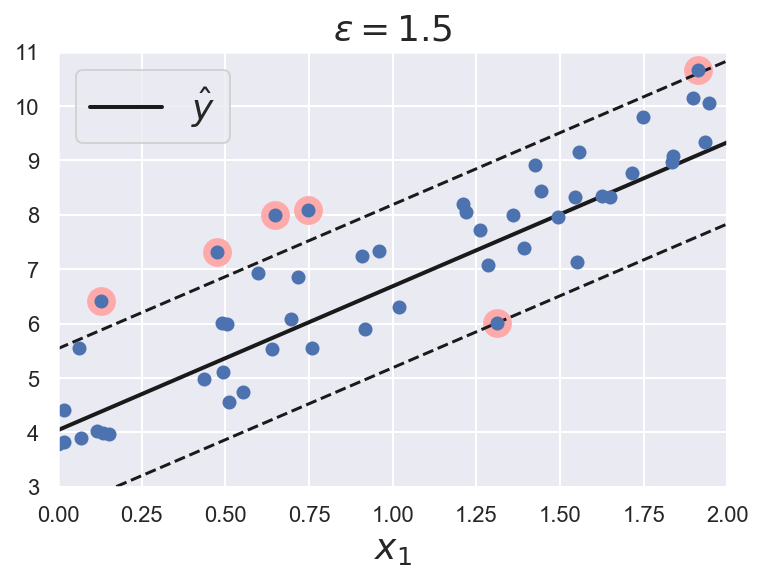

In [13]:
plot_svm_regression(svm_reg1, X, y, [0,2,3,11])
plt.title(r'$\epsilon = {}$'.format(svm_reg1.epsilon), fontsize=18);

#### 2.9 입실론 0.5 설정 결과

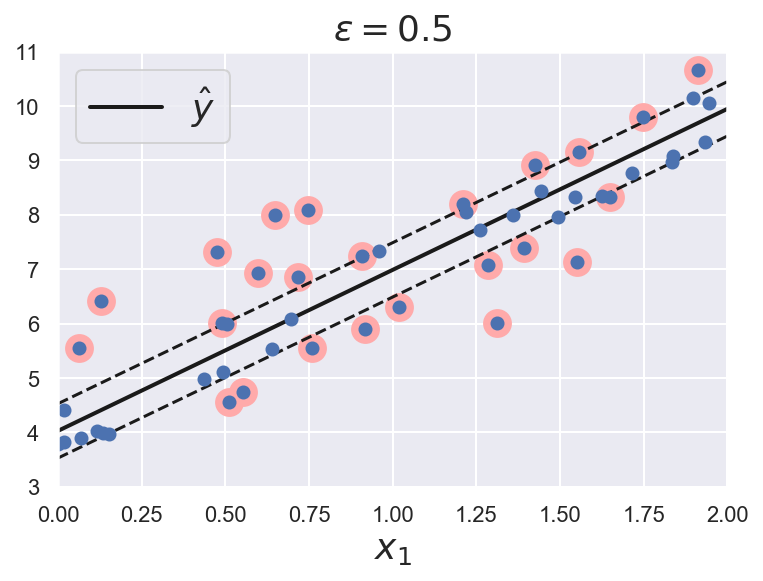

In [14]:
plot_svm_regression(svm_reg2, X, y, [0,2,3,11])
plt.title(r'$\epsilon = {}$'.format(svm_reg2.epsilon), fontsize=18);

#### 2.10 비선형 회귀 테스트를 위한 회귀

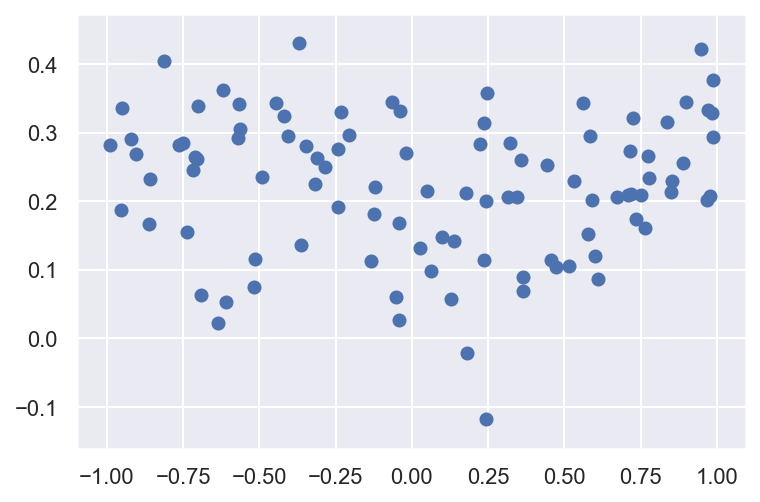

In [16]:
m = 100
X = 2 * np.random.rand(m,1) - 1
y = (0.2 + 0.1 * 0.5 * X**2 + np.random.randn(m,1)/10).ravel()

plt.scatter(X,y);

#### 2.11 비선형 회귀에 SVM 적용

In [17]:
from sklearn.svm import SVR

svm_poly_reg1 = SVR(kernel='poly', degree=2, C=100, epsilon=0.1, gamma='scale')
svm_poly_reg2 = SVR(kernel='poly', degree=2, C=0.01, epsilon=0.1, gamma='scale')
svm_poly_reg1.fit(X,y)
svm_poly_reg2.fit(X,y)

SVR(C=0.01, degree=2, kernel='poly')

#### 2.12 이번에는 조금 멋지게 그려볼까

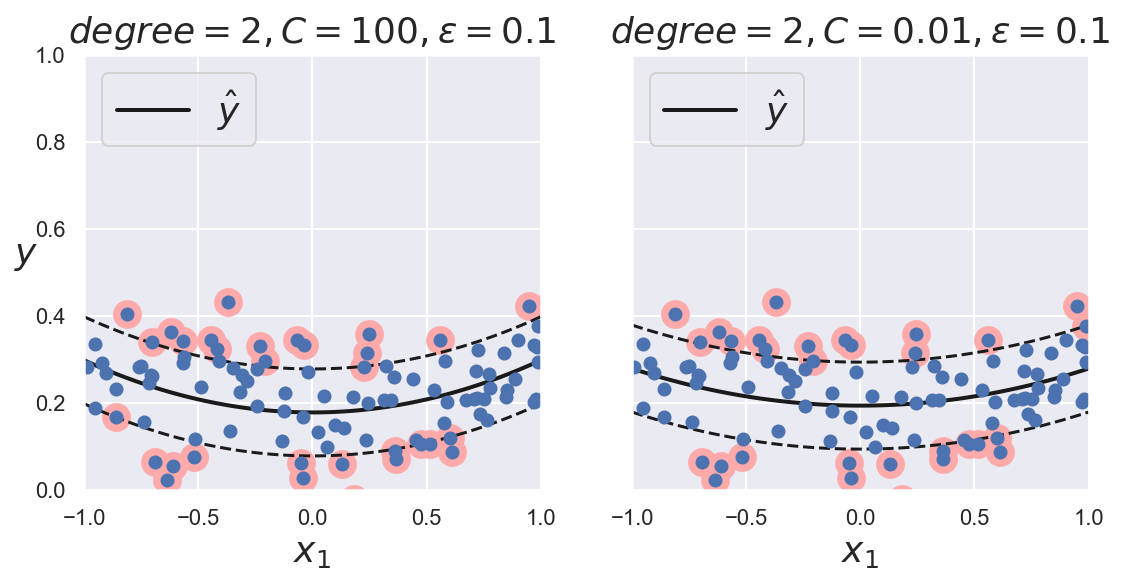

In [18]:
fig, axes = plt.subplots(ncols=2, figsize=(9,4), sharey=True)
plt.sca(axes[0])
plot_svm_regression(svm_poly_reg1, X, y, [-1, 1, 0, 1])
plt.title(r'$degree={}, C={}, \epsilon = {}$'.format(svm_poly_reg1.degree,
                                                    svm_poly_reg1.C,
                                                    svm_poly_reg1.epsilon),
          fontsize=18)
plt.ylabel(r'$y$',fontsize=18, rotation=0)
plt.sca(axes[1])
plot_svm_regression(svm_poly_reg2, X, y, [-1, 1, 0, 1])
plt.title(r'$degree={}, C={}, \epsilon = {}$'.format(svm_poly_reg2.degree,
                                                    svm_poly_reg2.C,
                                                    svm_poly_reg2.epsilon),
          fontsize=18);